# Musically motivated metrics visualisations


In [1]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# for prototyping piano-roll visualizations
import pretty_midi as pm
import librosa
import librosa.display
import mir_eval
import mir_eval.display

import partitura as pt

import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('..')

import mpteval

from mpteval.metrics.objective import compute_transcription_benchmark_framewise, ir_metrics_notewise, ir_metrics_notewise_with_velocity
from mpteval.metrics.subjective import perceptual_error_rate

from mpteval.metrics_feature.articulation import skyline_melody_identification, get_kor_stream_funcs
from mpteval.metrics_feature.timing import get_ioi_stream_func
from mpteval.metrics_feature.dynamics import get_upper_lower_stream_dynamic_range
from mpteval.metrics_feature.harmony import get_tonal_tension_feature_func

from mpteval.utils_plotting import (
    plot_piano_roll_from_stream_note_arrays,
    plot_correlation
)

In [2]:
ref_note_array = pt.load_performance_midi(mpteval.REF_MID).note_array()
pred_note_array = pt.load_performance_midi(mpteval.PRED_MID).note_array()

## Articulation

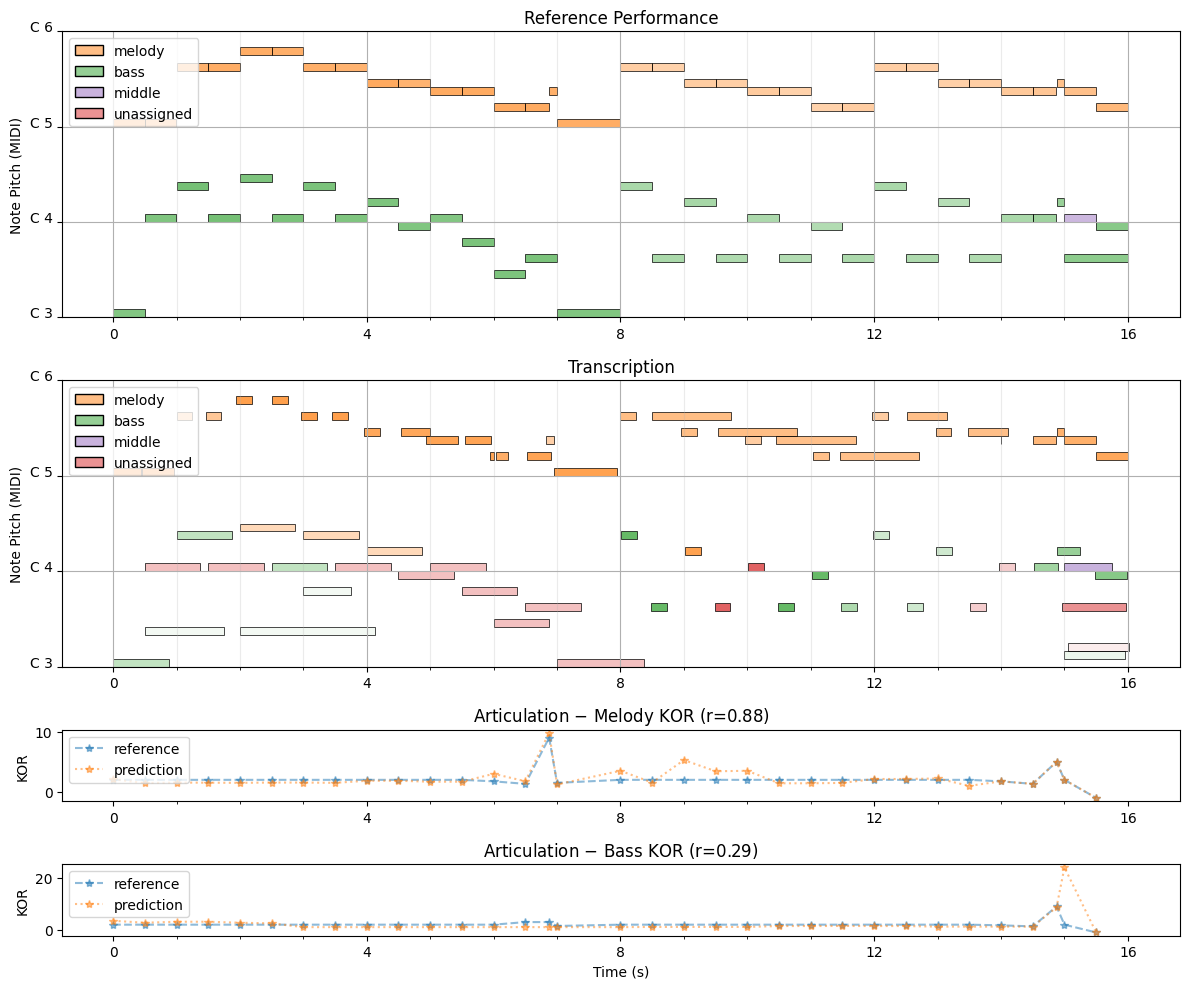

In [3]:
# separate streams
ref_melody, ref_bass, ref_middle = skyline_melody_identification(note_array=ref_note_array)
ref_unassigned = [note for note in ref_note_array if (note not in ref_melody) and (note not in ref_middle) and (note not in ref_bass)]
pred_melody, pred_bass, pred_middle = skyline_melody_identification(note_array=pred_note_array)
pred_unassigned = [note for note in pred_note_array if (note not in pred_melody) and (note not in pred_middle) and (note not in pred_bass)]
# collect in a dict
ref_stream_note_arrays = {'melody': ref_melody, 'bass': ref_bass, 'middle': ref_middle, 'unassigned': ref_unassigned}
pred_stream_note_arrays = {'melody': pred_melody, 'bass': pred_bass, 'middle': pred_middle, 'unassigned': pred_unassigned}

# get reference onsets
onsets = np.unique(ref_note_array["onset_sec"])
# get interpolation funcs for ref and pred
kor_melody_ref_func, kor_bass_ref_func = get_kor_stream_funcs(ref_note_array)
kor_melody_pred_func, kor_bass_pred_func = get_kor_stream_funcs(pred_note_array)
# fit the interpolation funcs
kor_melody_ref = kor_melody_ref_func(onsets)
kor_bass_ref = kor_bass_ref_func(onsets)
kor_melody_pred = kor_melody_pred_func(onsets)
kor_bass_pred = kor_bass_pred_func(onsets)
# get correlation
melody_kor_corr = np.corrcoef(kor_melody_ref, kor_melody_pred)[0, 1]
bass_kor_corr = np.corrcoef(kor_bass_ref, kor_bass_pred)[0, 1]

# plot it all
fig, axs = plt.subplots(4, 1, figsize=(16-4, 8+2), sharex=True, gridspec_kw={'height_ratios': [4, 4, 1, 1]})
# plot piano rolls
plot_piano_roll_from_stream_note_arrays(ref_stream_note_arrays, title='Reference Performance', ax=axs[0], lw=0.5, alpha=0.5)
axs[0].set_title('Reference Performance')
plot_piano_roll_from_stream_note_arrays(pred_stream_note_arrays, title='Transcription', ax=axs[1], lw=0.5, alpha=0.5)
axs[1].set_title('Transcription')
# plot correlations
plot_correlation(onsets, kor_melody_ref, kor_melody_pred, stream='melody', feature='KOR', title='Articulation', ax=axs[2])
plot_correlation(onsets, kor_bass_ref, kor_bass_pred, stream='bass', feature='KOR', title='Articulation', ax=axs[3])
# add x label only for last axis
ax = axs[3]
ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()


## Timing

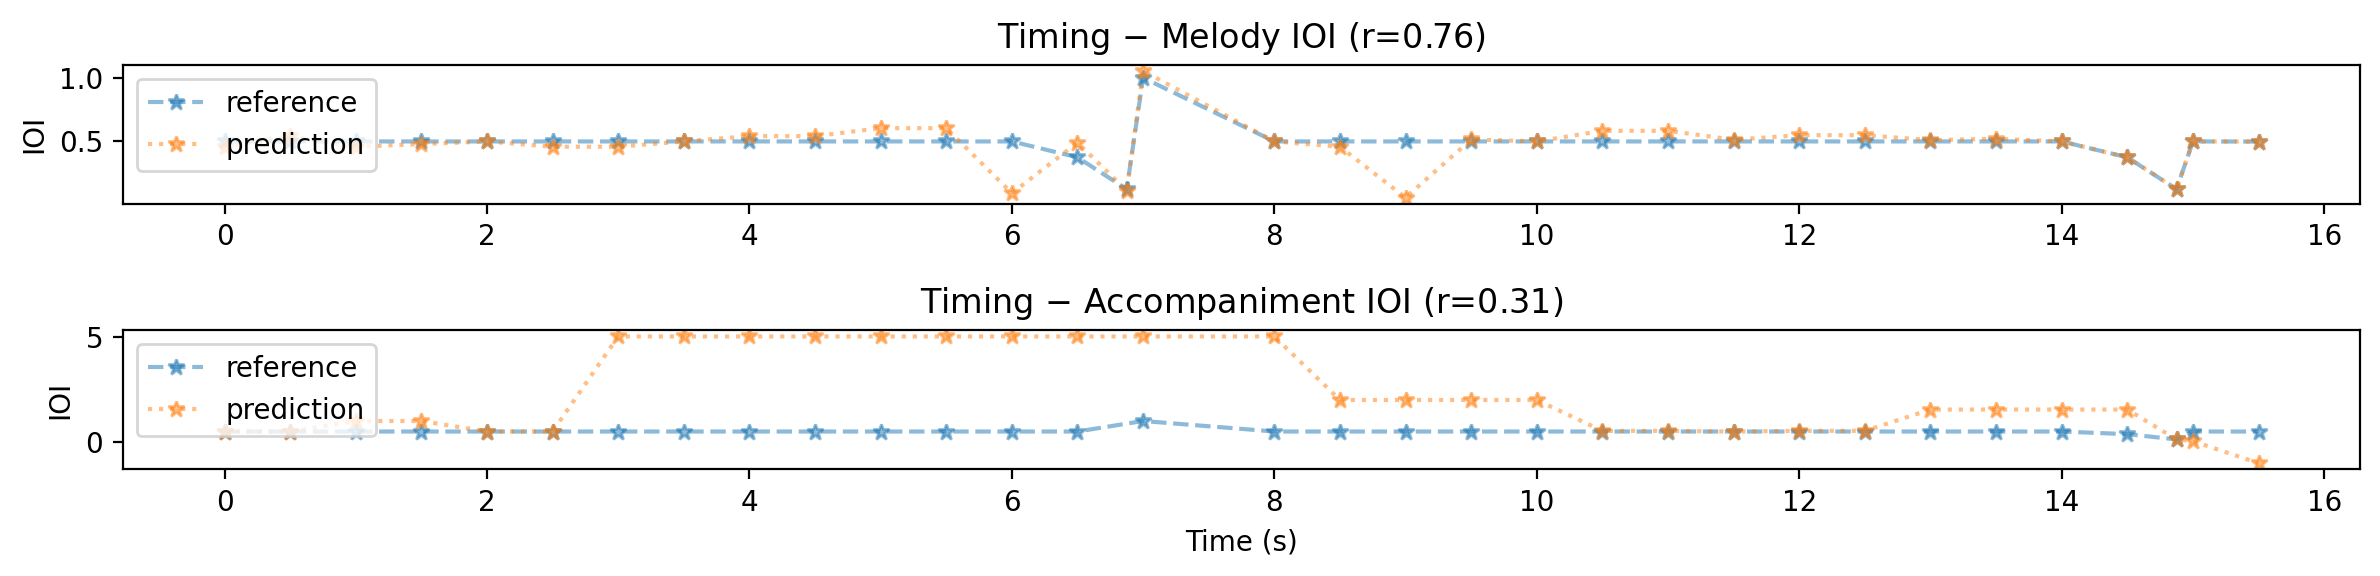

In [4]:
# get reference onsets 
ref_melody_onsets = np.unique(ref_melody['onset_sec'])
ref_bass_onsets = np.unique(ref_bass['onset_sec'])
# get interpolation funcs for ref and pred
ref_ioi_melody_func = get_ioi_stream_func(ref_melody)
ref_ioi_bass_func = get_ioi_stream_func(ref_bass)
pref_ioi_melody_func = get_ioi_stream_func(pred_melody)
pref_ioi_acc_func = get_ioi_stream_func(pred_bass)
# fit the interpolation funcs
ref_melody_ioi = ref_ioi_melody_func(ref_melody_onsets)
ref_bass_ioi = ref_ioi_bass_func(ref_bass_onsets)
pred_melody_ioi = pref_ioi_melody_func(ref_melody_onsets)
pred_bass_ioi = pref_ioi_acc_func(ref_bass_onsets)
# get correlation
melody_ioi_corr = np.corrcoef(ref_melody_ioi, pred_melody_ioi)[0, 1]
acc_ioi_corr = np.corrcoef(pred_bass_ioi, pred_bass_ioi)[0, 1]

# plot it
fig, axs = plt.subplots(2, 1, figsize=(16-4, 3), sharex=True, gridspec_kw={'height_ratios': [1, 1]})
plot_correlation(ref_melody_onsets, ref_melody_ioi, pred_melody_ioi, stream='melody', feature='IOI', title='Timing', ax=axs[0])
plot_correlation(ref_bass_onsets, ref_bass_ioi, pred_bass_ioi, stream='accompaniment', feature='IOI', title='Timing', ax=axs[1])
ax = axs[1]
ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

## Harmony

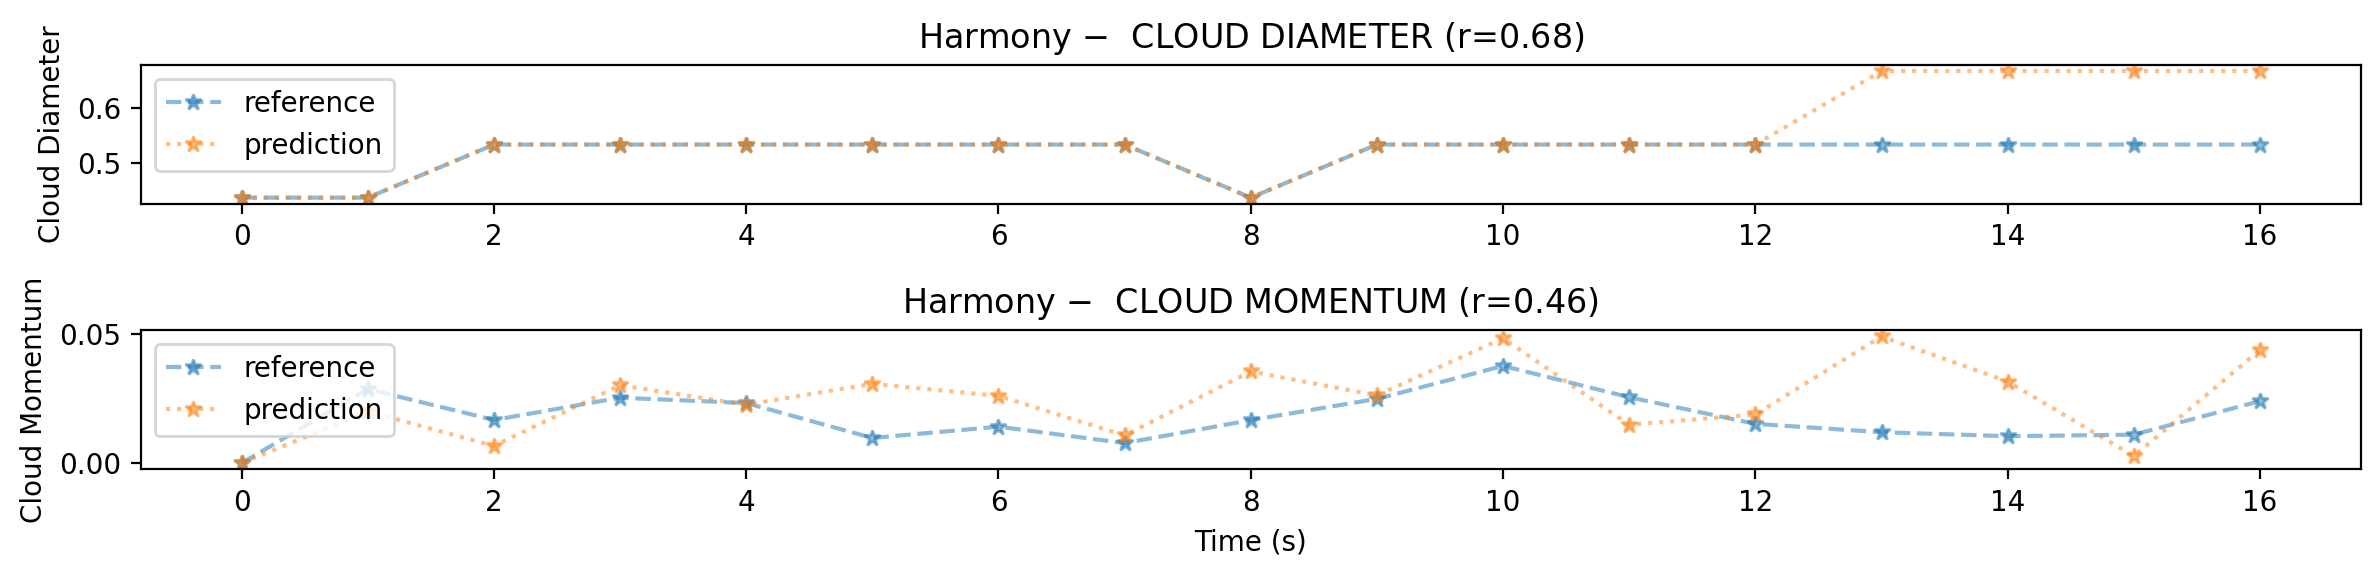

In [5]:
# global params: window size, step size
ws, ss = 5, 1
# get feature arrays for ref and pred
onsets_harm, ref_cd, cd_func = get_tonal_tension_feature_func(ref_note_array, 'cloud_diameter', ws, ss,return_onsets=True)
ref_cm, cm_func = get_tonal_tension_feature_func(ref_note_array, 'cloud_momentum', ws, ss)
# get interp func for pred and fit 
_, pred_cd_func = get_tonal_tension_feature_func(pred_note_array, 'cloud_diameter', ws, ss)
_, pred_cm_func = get_tonal_tension_feature_func(pred_note_array, 'cloud_momentum', ws, ss)
pred_cd = pred_cd_func(onsets_harm)
pred_cm = pred_cm_func(onsets_harm)
# get correlation
cd_corr = np.corrcoef(ref_cd, pred_cd)[0, 1]
cm_corr = np.corrcoef(ref_cm, pred_cm)[0, 1]

# plot it
fig, axs = plt.subplots(2, 1, figsize=(16-4, 3), sharex=True, gridspec_kw={'height_ratios': [1, 1]})
plot_correlation(onsets_harm, ref_cd, pred_cd, stream='', feature='Cloud Diameter', title='Harmony', ax=axs[0])
plot_correlation(onsets_harm, ref_cm, pred_cm, stream='', feature='Cloud Momentum', title='Harmony', ax=axs[1])
ax = axs[1]
ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

## Dynamics

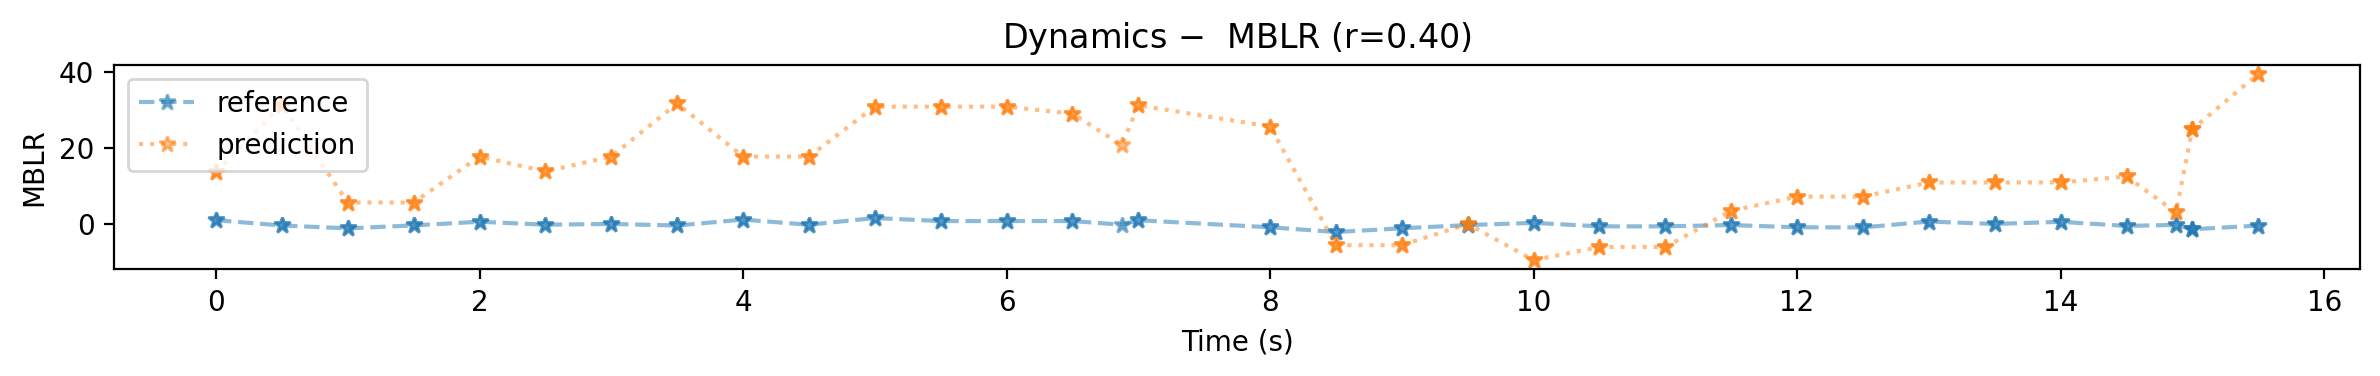

In [6]:
# global params
r_b = 44.0
# get interp funcs for ref and pred
dynamic_range_ref_func, _, _, ref_upper_voice, ref_lower_voice = get_upper_lower_stream_dynamic_range(note_array=ref_note_array, r_b=r_b)
ref_unassigned = [note for note in ref_note_array if (note not in ref_upper_voice) and (note not in ref_lower_voice)]
dynamic_range_pred_func, _, _, pred_upper_voice, pred_lower_voice = get_upper_lower_stream_dynamic_range(note_array=pred_note_array, r_b=r_b)
pred_unassigned = [note for note in pred_note_array if (note not in pred_upper_voice) and (note not in pred_lower_voice)]
# get ref onsets, and fit interp funcs
onsets_dyn = ref_note_array["onset_sec"]
ref_dyn_rang = dynamic_range_ref_func(onsets_dyn)
pred_dyn_rang = dynamic_range_pred_func(onsets_dyn)
# get correlation
dyn_corr = np.corrcoef(ref_dyn_rang, pred_dyn_rang)[0, 1]

# plot it
fig, axs = plt.subplots(1, figsize=(16-4, 2), sharex=True, gridspec_kw={'height_ratios': [1]})
# plot correlations
plot_correlation(onsets_dyn, ref_dyn_rang, pred_dyn_rang, stream='', feature='MBLR', title='Dynamics', ax=axs)
axs.set_xlabel('Time (s)');

plt.tight_layout()
plt.show()